In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("test.csv",encoding="latin1")

print(df.head())

       textID                                               text sentiment  \
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh   neutral   
1  96d74cb729   Shanghai is also really exciting (precisely -...  positive   
2  eee518ae67  Recession hit Veronique Branquinho, she has to...  negative   
3  01082688c6                                        happy bday!  positive   
4  33987a8ee5             http://twitpic.com/4w75p - I like it!!  positive   

  Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  \
0       morning        0-20  Afghanistan        38928346.0         652860.0   
1          noon       21-30      Albania         2877797.0          27400.0   
2         night       31-45      Algeria        43851044.0        2381740.0   
3       morning       46-60      Andorra           77265.0            470.0   
4          noon       60-70       Angola        32866272.0        1246700.0   

   Density (P/Km²)  
0             60.0  
1            1

In [ ]:
display(df[['text', 'sentiment']].head())

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [ ]:
import re

def cleanDF(text):
  if not isinstance(text, str):
    return ""

  text = text.lower()

  text = re.sub(r'[^a-zA-Z0-9\s]','',text)

  return text

df["cleaned_text"] = df["text"].apply(cleanDF)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df["cleaned_text"])
sequence = tokenizer.texts_to_sequences(df["cleaned_text"])
index_sequence = tokenizer.index_word

max_seq = 0

for seq in sequence:
  max_seq = max(max_seq, len(seq))

padded_sequence = pad_sequences(sequence, maxlen=max_seq, padding='post', truncating='post')

# Encode target variable (sentiment)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["sentiment"])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequence, y, test_size=0.2, random_state=42)

{1: 'i', 2: 'to', 3: 'the', 4: 'a', 5: 'my', 6: 'and', 7: 'you', 8: 'it', 9: 'for', 10: 'is', 11: 'in', 12: 'im', 13: 'of', 14: 'me', 15: 'on', 16: 'have', 17: 'so', 18: 'that', 19: 'but', 20: 'its', 21: 'just', 22: 'be', 23: 'was', 24: 'not', 25: 'with', 26: 'at', 27: 'day', 28: 'good', 29: 'this', 30: 'all', 31: 'now', 32: 'out', 33: 'up', 34: 'like', 35: 'get', 36: 'too', 37: 'love', 38: 'go', 39: 'got', 40: 'dont', 41: 'are', 42: 'do', 43: 'no', 44: 'your', 45: 'know', 46: 'cant', 47: 'going', 48: 'work', 49: 'today', 50: 'u', 51: 'what', 52: 'am', 53: 'from', 54: 'can', 55: 'happy', 56: 'back', 57: 'lol', 58: 'time', 59: 'will', 60: 'about', 61: 'one', 62: 'see', 63: 'we', 64: 'really', 65: 'much', 66: 'an', 67: 'if', 68: 'as', 69: 'well', 70: 'how', 71: 'think', 72: 'night', 73: 'new', 74: 'oh', 75: 'want', 76: 'still', 77: 'miss', 78: 'thanks', 79: 'been', 80: 'thats', 81: 'some', 82: 'last', 83: 'here', 84: 'when', 85: 'home', 86: 'they', 87: 'then', 88: '2', 89: 'need', 90: 'm

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM

num_classes = len(label_encoder.classes_)

model = Sequential()
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.add(Embedding(input_dim=len(index_sequence) + 1,input_length=max_seq,output_dim=128))
model.add(LSTM(units=128))
model.add(Dense(units=num_classes))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train,y_train,epochs=10)

Epoch 1/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.2168 - loss: 1.7159
Epoch 2/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 3/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 4/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 5/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 6/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 7/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 8/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 9/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.2059 - loss: 1.3863
Epoch 10/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.2059 - loss: 1.3863


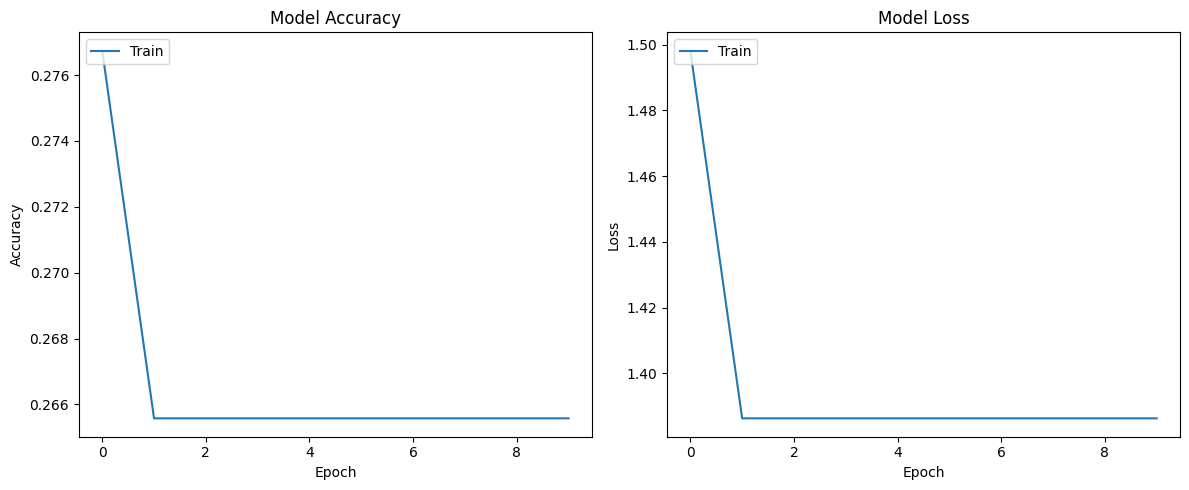

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2170 - loss: 1.3863
Test Loss: 1.3863
Test Accuracy: 0.2170


In [ ]:
def testFunction(text):
  cleaned_sentence = cleanDF(text)

  sequence = tokenizer.texts_to_sequences([cleaned_sentence])

  padded_sequence = pad_sequences(sequence,maxlen= max_seq, padding='post', truncating='post')

  prediction = model.predict(padded_sequence)

  predicted_class = label_encoder.inverse_transform([prediction.argmax()])

  return predicted_class

# Test with several phrases
test_phrases = [
    "This is a fantastic product, I absolutely love it!",
    "I am so disappointed with the service, it was terrible.",
    "The movie was okay, nothing special.",
    "I feel great today!",
    "This is the worst day ever."
]

print("Sentiment Predictions:")
for phrase in test_phrases:
    sentiment = testFunction(phrase)
    print(f"Phrase: '{phrase}' -> Predicted Sentiment: '{sentiment}'")



Sentiment Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Phrase: 'This is a fantastic product, I absolutely love it!' -> Predicted Sentiment: '['negative']'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Phrase: 'I am so disappointed with the service, it was terrible.' -> Predicted Sentiment: '['negative']'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Phrase: 'The movie was okay, nothing special.' -> Predicted Sentiment: '['negative']'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Phrase: 'I feel great today!' -> Predicted Sentiment: '['negative']'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Phrase: 'This is the worst day ever.' -> Predicted Sentiment: '['negative']'
